# Notebook 4: Early Warning Model

## Objective
Build a supervised machine learning model to predict which banks are at risk of capital deterioration in the following quarter. A bank is defined as "at risk" if its CET1 ratio falls below 15% in the next period, a conservative threshold above the regulatory minimum that signals limited capital buffers.

## 1. Target Variable Construction

A bank is labelled "at risk" (1) if its CET1 ratio falls below 15% in the following quarter, and "safe" (0) otherwise.

The dataset contains 337 observations across 3 periods (the last period is excluded as no future data is available).
22% of observations are labelled "at risk", providing a sufficient base rate for model training.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

# Load full dataset
df = pd.read_csv("banking_indicators_clean.csv")
df['Period'] = pd.to_datetime(df['Period'])

# Remove outliers
df = df[df['CET1_ratio'] < 50].copy()

# Sort by bank and period
df = df.sort_values(['LEI_Code', 'Period']).reset_index(drop=True)

# Create target variable: CET1 ratio below 15% in the NEXT period
df['CET1_ratio_next'] = df.groupby('LEI_Code')['CET1_ratio'].shift(-1)
df['at_risk'] = (df['CET1_ratio_next'] < 15).astype(int)

# Drop last period for each bank
df_model = df.dropna(subset=['CET1_ratio_next']).copy()

print(df_model.shape)
print(df_model['at_risk'].value_counts())
print(df_model['at_risk'].value_counts(normalize=True).round(3))

(337, 10)
at_risk
0    263
1     74
Name: count, dtype: int64
at_risk
0    0.78
1    0.22
Name: proportion, dtype: float64


## 2. Feature Engineering and Train/Test Split

Three features are used:
- **CET1_ratio**: current capital adequacy ratio
- **total_assets**: bank size as a control variable  
- **CET1_change**: quarter-on-quarter change in CET1 ratio, capturing momentum and deterioration signals

The dataset is split 80/20 into training and test sets, with stratification to preserve the class balance.

In [2]:
# Define features for the model
features = ['CET1_ratio', 'total_assets']

# Add CET1 change from previous period as a signal
df_model['CET1_change'] = df_model.groupby('LEI_Code')['CET1_ratio'].diff()
features.append('CET1_change')

# Drop rows where CET1_change is NaN (first period per bank)
df_model = df_model.dropna(subset=features).copy()

X = df_model[features]
y = df_model['at_risk']

# Train/test split - stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("At risk in training:", y_train.sum(), "/", len(y_train))
print("At risk in test:", y_test.sum(), "/", len(y_test))

Training set: (160, 3)
Test set: (40, 3)
At risk in training: 39 / 160
At risk in test: 10 / 40


## 3. Model Training and Cross-Validation

Both models achieve very high cross-validated AUC scores:
- Logistic Regression: 0.980 (std=0.027)
- Random Forest: 0.934 (std=0.076)

Logistic Regression outperforms Random Forest, which is common with small datasets where simpler models generalise better.

Note: the high AUC is partly explained by the strong autocorrelation of CET1 ratios over time (a bank with a low CET1 today is very 
likely to have a low CET1 next quarter). This is a known limitation of short-horizon early warning models.

In [3]:
# Train Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Cross-validation scores (5-fold)
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc')
rf_cv = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='roc_auc')

print("Logistic Regression - CV AUC: mean={:.3f}, std={:.3f}".format(lr_cv.mean(), lr_cv.std()))
print("Random Forest - CV AUC: mean={:.3f}, std={:.3f}".format(rf_cv.mean(), rf_cv.std()))

Logistic Regression - CV AUC: mean=0.980, std=0.027
Random Forest - CV AUC: mean=0.934, std=0.076


### Model Evaluation on Test Set

Both models perform very well on the held-out test set:

**Logistic Regression (preferred model):**
- Accuracy: 95% — correctly classifies 38 out of 40 banks
- Precision for "at risk": 100% — no false alarms
- Recall for "at risk": 80% — catches 8 out of 10 at-risk banks
- AUC: 0.98

**Random Forest:**
- Accuracy: 93%
- Precision for "at risk": 89%
- Recall for "at risk": 80%
- AUC: 0.97

**Key trade-off:** Logistic Regression achieves perfect precision (0 false alarms) at the cost of missing 2 at-risk banks (recall=0.80). In a supervisory context, missing a vulnerable bank is more costly than a false alarm, a lower classification threshold could improve recall at the expense of precision.

The Logistic Regression is selected as the final model given its higher AUC, better precision and greater interpretability for policy purposes.

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.80      0.89        10

    accuracy                           0.95        40
   macro avg       0.97      0.90      0.93        40
weighted avg       0.95      0.95      0.95        40

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.89      0.80      0.84        10

    accuracy                           0.93        40
   macro avg       0.91      0.88      0.90        40
weighted avg       0.92      0.93      0.92        40



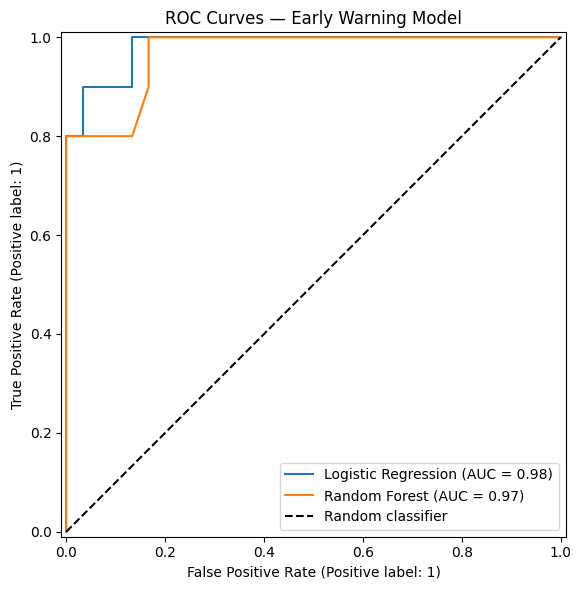

In [4]:
# Evaluate on test set
print("Logistic Regression")
print(classification_report(y_test, lr.predict(X_test_scaled)))

print("Random Forest")
print(classification_report(y_test, rf.predict(X_test_scaled)))

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test_scaled, y_test, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curves — Early Warning Model')
ax.legend()
plt.tight_layout()
plt.savefig('plot_07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

The logistic regression coefficients reveal which features drive the early warning signal:

**CET1_ratio (coefficient = -4.21):** By far the most important predictor.
The large negative coefficient confirms that a lower current CET1 ratio strongly increases the probability of falling below the threshold next quarter.
This is intuitive: capital adequacy is highly persistent over time.

**total_assets (coefficient = +0.22):** Larger banks are slightly more likely to be flagged as at risk. This reflects the finding from the clustering analysis that large systemic banks tend to operate with lower CET1 ratios.

**CET1_change (coefficient = -0.06):** A negative change in CET1 (deterioration) marginally increases risk probability, but the effect is small relative to the level. This suggests that the current level of capitalisation matters more than the recent trend for short-horizon predictions.

        Feature  Coefficient
0    CET1_ratio    -4.214036
1  total_assets     0.220828
2   CET1_change    -0.058403


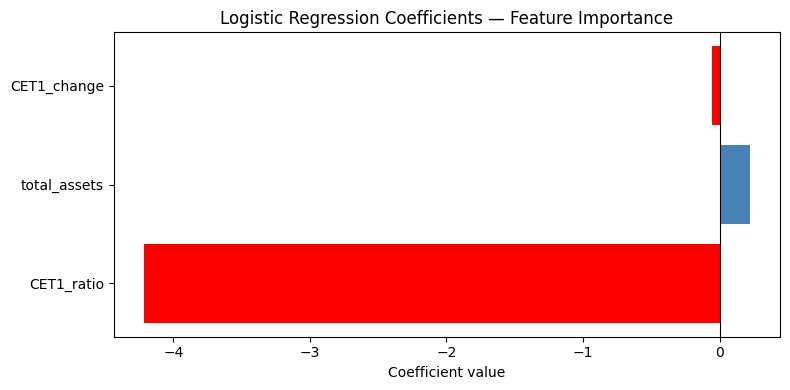

In [5]:
# Feature importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df)

# Plot
plt.figure(figsize=(8, 4))
colors = ['red' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients — Feature Importance')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('plot_08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Limitations

- **Short time horizon:** Only 4 quarters of data are available, limiting the model's ability to capture cyclical dynamics
- **Limited features:** NPL ratio, profitability and liquidity indicators would improve predictive power significantly
- **Autocorrelation:** CET1 ratios are highly persistent, which inflates model performance metrics
- **No macro scenarios:** A true stress test would incorporate adverse macroeconomic scenarios (GDP shock, interest rate spike)